# SIOC 251 – Homework 3 Monte Carlo Scattering PartI

**Name:** Claire Liu   
**Date:** 5/14/26

In [11]:
import numpy as np

### 5.1b Deriving the isotropic scattering angle sampler

**Given:** For isotropic scattering, the probability distribution for scattering angle is uniform in $\cos\Theta$:

$$P(\cos\Theta) = 1 \quad \text{for } \cos\Theta \in [-1, 1]$$

**Step 1: Compute the CDF**

$$C(\cos\Theta) = \frac{1}{2}\int_{-1}^{\cos\Theta} P(x)\,dx = \frac{1}{2}\int_{-1}^{\cos\Theta} 1\,dx = \frac{\cos\Theta + 1}{2}$$

The $\frac{1}{2}$ out front is a normalization factor so that $C(1) = 1$.

**Step 2: Set CDF equal to a uniform random number**

Since $C(\cos\Theta)$ maps $[-1,1] \to [0,1]$, we can set it equal to $\zeta \sim U(0,1)$:

$$\zeta = \frac{\cos\Theta + 1}{2}$$

**Step 3: Invert to solve for $\cos\Theta$**

$$2\zeta = \cos\Theta + 1$$

$$\boxed{\cos\Theta = 2\zeta - 1}$$

This is the **inverse CDF sampling** technique: drawing $\zeta$ uniformly and transforming it through $C^{-1}$ produces samples distributed according to $P(\cos\Theta)$.

In [10]:
def monte_carlo_scattering(n_photons, tau_star, omega=1.0, mu0=1.0, z_atm=1.0):
    dz_per_tau = z_atm / tau_star
    n_direct = 0
    n_diffuse = 0
    n_reflected = 0
    n_absorbed = 0

    for i in range(n_photons):
        # Initial direction: incoming at zenith angle theta0 = arccos(mu0)
        theta = np.arccos(mu0)  # zenith angle of propagation (downward)
        phi_dir = 0.0           # azimuthal angle (arbitrary for initial beam)

        # Propagation vector k = (cos(phi)*sin(theta), sin(phi)*sin(theta), -cos(theta))
        kx = np.cos(phi_dir) * np.sin(theta)
        ky = np.sin(phi_dir) * np.sin(theta)
        kz = -np.cos(theta)  # negative = downward

        z = z_atm
        n_scatters = 0
        alive = True

        while alive:
            delta_tau = -np.log(np.random.uniform())
            ds = delta_tau * dz_per_tau

            # Update position: only z matters in plane-parallel
            z_new = z + kz * ds

            if z_new >= z_atm:
                n_reflected += 1
                alive = False
            elif z_new <= 0:
                if n_scatters == 0:
                    n_direct += 1
                else:
                    n_diffuse += 1
                alive = False
            else:
                z = z_new

                if np.random.uniform() < omega:
                    n_scatters += 1

                    # Sample scattering angles
                    cos_Theta = 2 * np.random.uniform() - 1
                    sin_Theta = np.sqrt(1 - cos_Theta**2)
                    Phi = 2 * np.pi * np.random.uniform()

                    # Scattered direction in photon coordinates
                    kp_x = sin_Theta * np.cos(Phi)
                    kp_y = sin_Theta * np.sin(Phi)
                    kp_z = cos_Theta

                    # Build local coordinate system (Appendix A.2)
                    # z_p = k0 (incoming direction)
                    zp = np.array([kx, ky, kz])

                    # x_p: horizontal, perpendicular to z_p
                    kxy = np.sqrt(kx**2 + ky**2)
                    if kxy > 1e-8:
                        xp = np.array([-ky, kx, 0.0]) / kxy
                    else:
                        xp = np.array([1.0, 0.0, 0.0])

                    # y_p = z_p x x_p
                    yp = np.cross(zp, xp)

                    # Rotate to model coordinates (Appendix A.4)
                    k_new = kp_x * xp + kp_y * yp + kp_z * zp

                    # Normalize to prevent drift
                    k_new = k_new / np.linalg.norm(k_new)

                    kx, ky, kz = k_new
                else:
                    n_absorbed += 1
                    alive = False

    return {
        'direct_T': n_direct / n_photons,
        'diffuse_T': n_diffuse / n_photons,
        'total_T': (n_direct + n_diffuse) / n_photons,
        'albedo': n_reflected / n_photons,
        'absorptance': n_absorbed / n_photons,
    }

### 5.2 Verifications

Verification 1: I used Beer's law  𝑇=𝑒−𝜏∗/𝜇 to calculate the transmittance and compared it with the results from the model, they should give similar values.

In [14]:
result = monte_carlo_scattering(n_photons=100000, tau_star=0.5, omega=0, mu0=np.cos(0.78))
tau_star = 0.5
mu = np.cos(0.78)
print(f"MC transmittance: {result['total_T']:.4f}")
print(f"Beer's Law:       {np.exp(-tau_star / mu):.4f}")

MC transmittance: 0.4926
Beer's Law:       0.4949


Verification 2: Every photon must end up somewhere, so T + A + R should be approximately 1.

In [18]:
result = monte_carlo_scattering(n_photons=100000, tau_star=0.5, omega=0.5, mu0=1)
print(f"MC transmittance: {result['total_T']:.4f}")
print(f"MC Absorptance:   {result['absorptance']:.4f}")
print(f"MC Reflectance:   {result['albedo']:.4f}")
print(f"Total:   {result['albedo']+result['total_T']+result['absorptance']:.4f}")

MC transmittance: 0.6743
MC Absorptance:   0.2528
MC Reflectance:   0.0729
Total:   1.0000


### 5.3 Questions

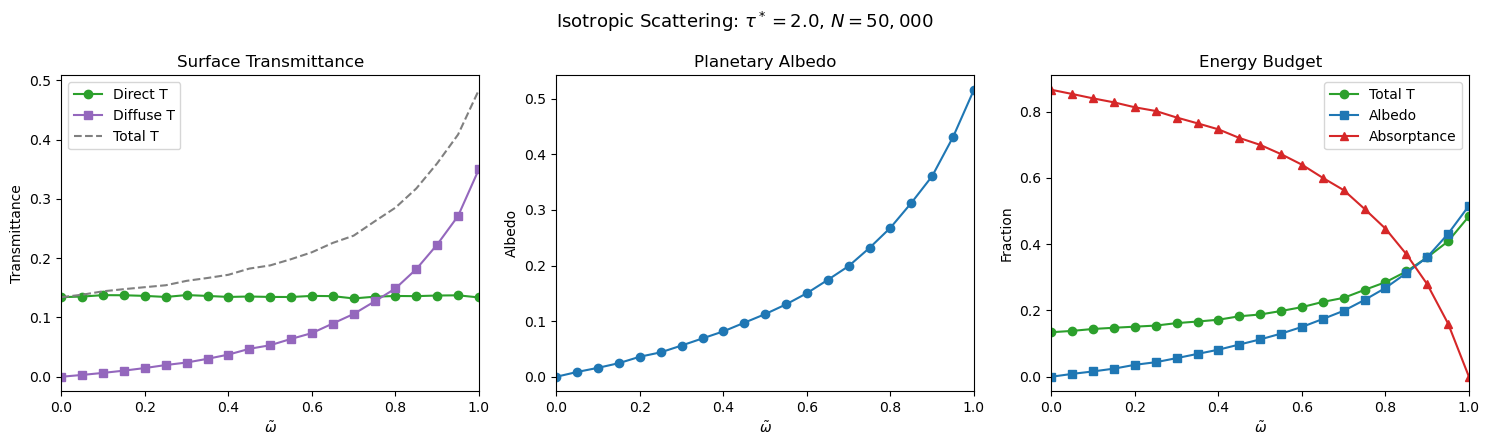

In [24]:
# --- Run omega sweep ---
n_photons = 50000
tau_star = 2.0
omegas = np.arange(0, 1.05, 0.05)

results = {k: [] for k in ['direct_T', 'diffuse_T', 'total_T', 'albedo', 'absorptance']}

for w in omegas:
    r = monte_carlo_scattering(n_photons, tau_star, omega=w)
    for k in results:
        results[k].append(r[k])

for k in results:
    results[k] = np.array(results[k])

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

# Panel 1: Direct & Diffuse Transmittance
axes[0].plot(omegas, results['direct_T'], 'o-', label='Direct T', color='tab:green')
axes[0].plot(omegas, results['diffuse_T'], 's-', label='Diffuse T', color='tab:purple')
axes[0].plot(omegas, results['total_T'], '--', label='Total T', color='gray')
axes[0].set_xlabel(r'$\tilde{\omega}$')
axes[0].set_ylabel('Transmittance')
axes[0].set_title('Surface Transmittance')
axes[0].legend()
axes[0].set_xlim(0, 1)

# Panel 2: Albedo
axes[1].plot(omegas, results['albedo'], 'o-', color='tab:blue')
axes[1].set_xlabel(r'$\tilde{\omega}$')
axes[1].set_ylabel('Albedo')
axes[1].set_title('Planetary Albedo')
axes[1].set_xlim(0, 1)

# Panel 3: Full energy budget
axes[2].plot(omegas, results['total_T'], 'o-', label='Total T', color='tab:green')
axes[2].plot(omegas, results['albedo'], 's-', label='Albedo', color='tab:blue')
axes[2].plot(omegas, results['absorptance'], '^-', label='Absorptance', color='tab:red')
axes[2].set_xlabel(r'$\tilde{\omega}$')
axes[2].set_ylabel('Fraction')
axes[2].set_title('Energy Budget')
axes[2].legend()
axes[2].set_xlim(0, 1)

plt.suptitle(rf'Isotropic Scattering: $\tau^* = {tau_star}$, $N = {n_photons:,}$', fontsize=13)
plt.tight_layout()
plt.savefig('figures/transmittance.png', dpi=150, bbox_inches='tight')
plt.show()

**a.** For ˜ω increasing from 0 → 1, the the surface direct transmittance did not vary much but the diffuse transmittance increases. The albedo also increase as ˜ω increase.

### 5b

The single-scattering approximation to the RTE gives the diffuse radiance at the surface:

$$t_{\text{dif}}(\mu) = \frac{F_0 \tilde{\omega} \tau^*}{4\pi |\mu|} \, p(\cos\Theta)$$

This is the intensity (power per unit solid angle per unit area) reaching the surface in a specific direction $\mu = \cos\theta$. For isotropic scattering, the phase function $p(\cos\Theta) = 1$.

So:

$$t_{\text{dif}}(\mu) = \frac{F_0 \tilde{\omega} \tau^*}{4\pi |\mu|}$$

Our MC model doesn't measure radiance in one direction — it counts **all** photons that exit the bottom of the atmosphere in **any** downward direction. That's the hemispherically integrated flux (irradiance), not the radiance. So we need to integrate $t_{\text{dif}}(\mu)$ over the downward hemisphere.

The downward diffuse irradiance is:

$$F_{\text{dif}} = \int_{2\pi}^{\downarrow} t_{\text{dif}}(\mu) \cos\theta \, d\Omega$$

In spherical coordinates, $d\Omega = \sin\theta \, d\theta \, d\phi$ and $\cos\theta = \mu$, so switching to $\mu = \cos\theta$:

$$F_{\text{dif}} = \int_0^{2\pi} d\phi \int_0^{1} t_{\text{dif}}(\mu) \, \mu \, d\mu$$

### Substituting and simplifying

Plug in $t_{\text{dif}}(\mu) = \frac{F_0 \tilde{\omega} \tau^*}{4\pi \mu}$:

$$F_{\text{dif}} = \int_0^{2\pi} d\phi \int_0^{1} \frac{F_0 \tilde{\omega} \tau^*}{4\pi \mu} \cdot \mu \, d\mu$$

The $\mu$ in the cosine weighting cancels the $1/\mu$ in the radiance:

$$F_{\text{dif}} = \frac{F_0 \tilde{\omega} \tau^*}{4\pi} \int_0^{2\pi} d\phi \int_0^{1} d\mu$$

Both integrals are now trivial:

$$F_{\text{dif}} = \frac{F_0 \tilde{\omega} \tau^*}{4\pi} \cdot 2\pi \cdot 1 = \frac{F_0 \tilde{\omega} \tau^*}{2}$$


The incoming beam travels at angle $\theta_0$ from vertical, so its effective path through the atmosphere is longer by a factor of $1/\mu_0$. This means it encounters more scatterers, so $\tau^*$ in the expression above should be replaced by $\tau^*/\mu_0$:

$$F_{\text{dif}} = \frac{F_0 \tilde{\omega} \tau^*}{2\mu_0}$$

Normalizing by $F_0$ to get the dimensionless transmittance fraction (what the MC model computes):

$$\boxed{T_{\text{dif}} \approx \frac{\tilde{\omega} \tau^*}{2\mu_0}}$$


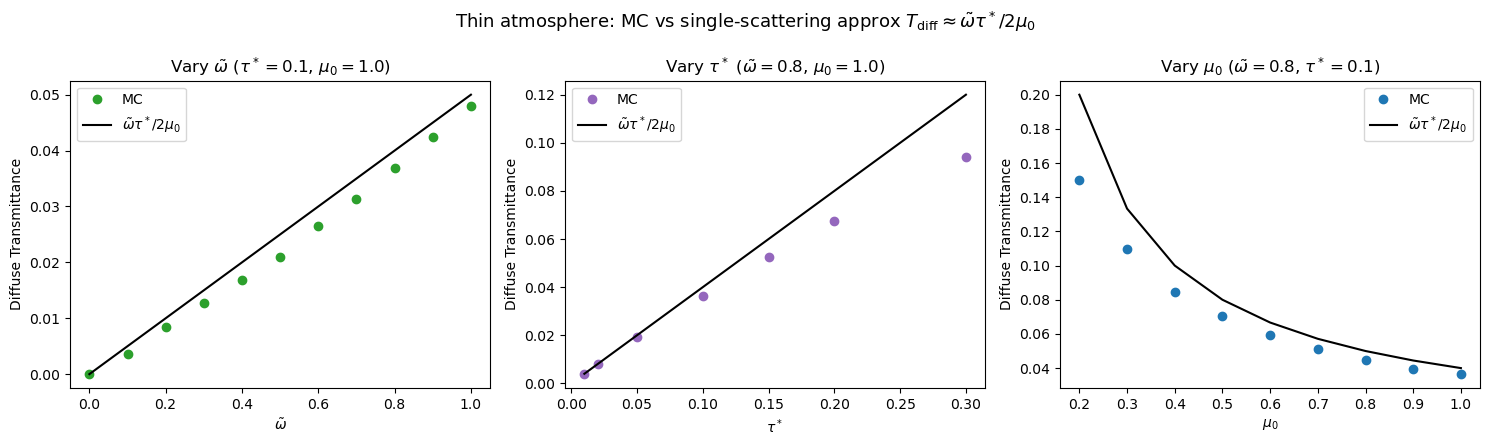

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# --- Thin atmosphere: vary omega, tau, mu independently ---

n_photons = 100000
F0 = 1.0
# Test 1: Fix tau=0.1, mu=1, vary omega
omegas = np.arange(0, 1.05, 0.1)
tau_test = 0.1
mu_test = 1.0
diffuse_vs_omega = []
for w in omegas:
    r = monte_carlo_scattering(n_photons, tau_test, omega=w, mu0=mu_test)
    diffuse_vs_omega.append(r['diffuse_T'])
diffuse_vs_omega = np.array(diffuse_vs_omega)
analytic_omega = omegas * tau_test / (2 * mu_test)

# Test 2: Fix omega=0.8, mu=1, vary tau
taus = np.array([0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3])
omega_test = 0.8
diffuse_vs_tau = []
for t in taus:
    r = monte_carlo_scattering(n_photons, t, omega=omega_test, mu0=mu_test)
    diffuse_vs_tau.append(r['diffuse_T'])
diffuse_vs_tau = np.array(diffuse_vs_tau)
analytic_tau = omega_test * taus / (2 * mu_test)

# Test 3: Fix omega=0.8, tau=0.1, vary mu
mus = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
diffuse_vs_mu = []
for m in mus:
    r = monte_carlo_scattering(n_photons, tau_test, omega=omega_test, mu0=m)
    diffuse_vs_mu.append(r['diffuse_T'])
diffuse_vs_mu = np.array(diffuse_vs_mu)
analytic_mu = omega_test * tau_test / (2 * mus)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(omegas, diffuse_vs_omega, 'o', label='MC', color='tab:green')
axes[0].plot(omegas, analytic_omega, '-', label=r'$\tilde{\omega}\tau^*/2\mu_0$', color='black')
axes[0].set_xlabel(r'$\tilde{\omega}$')
axes[0].set_ylabel('Diffuse Transmittance')
axes[0].set_title(rf'Vary $\tilde{{\omega}}$ ($\tau^*={tau_test}$, $\mu_0={mu_test}$)')
axes[0].legend()

axes[1].plot(taus, diffuse_vs_tau, 'o', label='MC', color='tab:purple')
axes[1].plot(taus, analytic_tau, '-', label=r'$\tilde{\omega}\tau^*/2\mu_0$', color='black')
axes[1].set_xlabel(r'$\tau^*$')
axes[1].set_ylabel('Diffuse Transmittance')
axes[1].set_title(rf'Vary $\tau^*$ ($\tilde{{\omega}}={omega_test}$, $\mu_0={mu_test}$)')
axes[1].legend()

axes[2].plot(mus, diffuse_vs_mu, 'o', label='MC', color='tab:blue')
axes[2].plot(mus, analytic_mu, '-', label=r'$\tilde{\omega}\tau^*/2\mu_0$', color='black')
axes[2].set_xlabel(r'$\mu_0$')
axes[2].set_ylabel('Diffuse Transmittance')
axes[2].set_title(rf'Vary $\mu_0$ ($\tilde{{\omega}}={omega_test}$, $\tau^*={tau_test}$)')
axes[2].legend()

plt.suptitle(r'Thin atmosphere: MC vs single-scattering approx $T_{\mathrm{diff}} \approx \tilde{\omega}\tau^*/2\mu_0$', fontsize=13)
plt.tight_layout()
plt.savefig('figures/5b.png', dpi=150, bbox_inches='tight')
plt.show()

b. Diffuse radiation/transmittance increases with ˜ω and τ, decreases with μ0. The MC model gives slightly lower values than the analytical prediction because the analytical solution only considers single scattering. The MC model allows photons to scatter again or get absorbed on the way down, which reduces the diffuse flux. The gap between MC and analytical is biggest around ω̃ ≈ 0.5 (where absorption and scattering compete the most), at larger τ* (more stuff to interact with), and at smaller μ₀ (longer paths through the atmosphere).

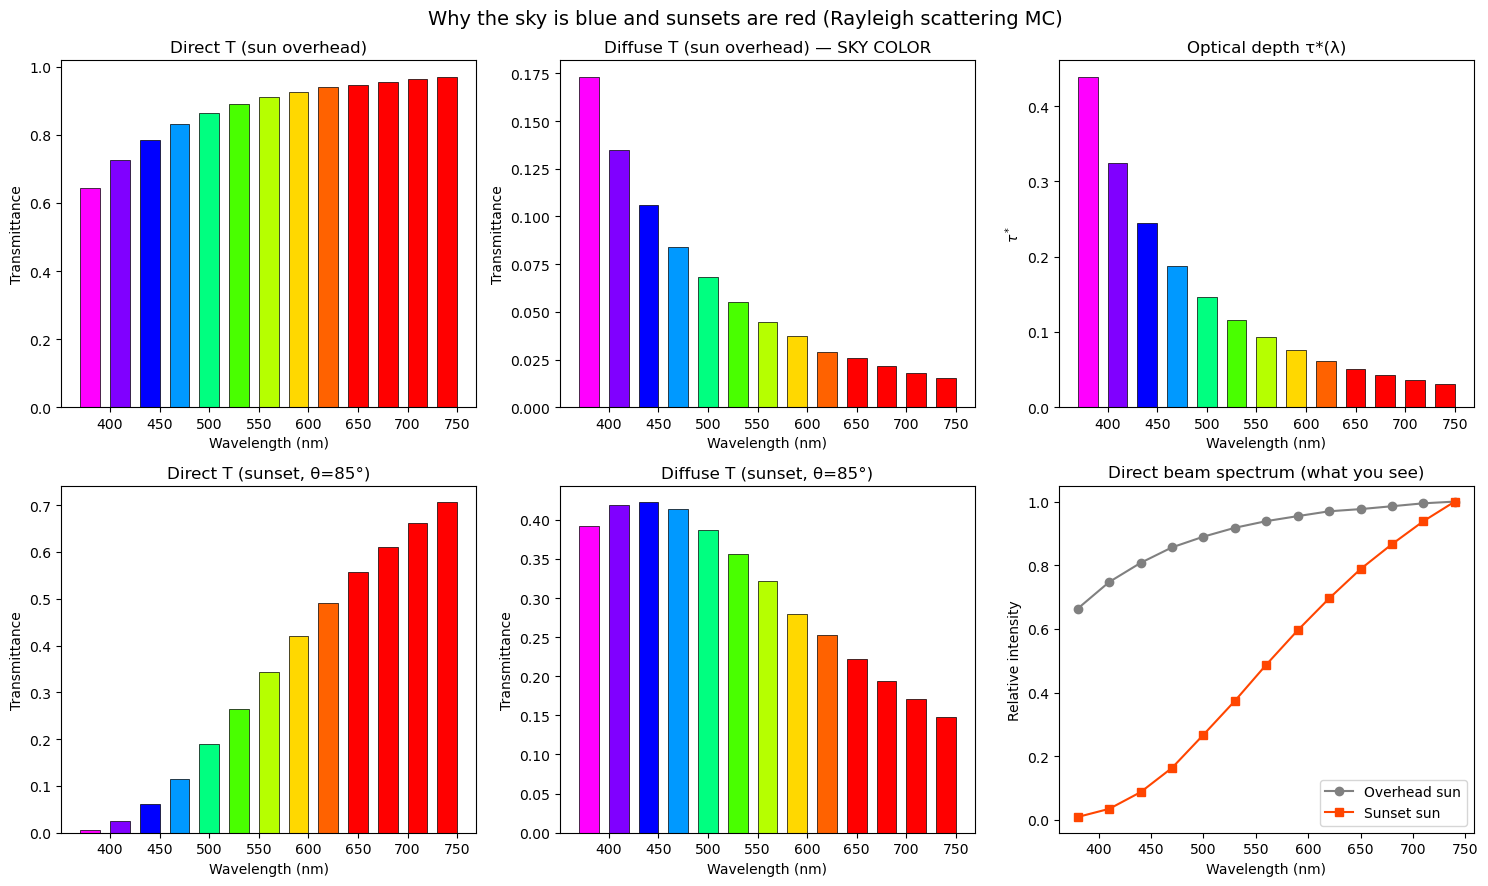

In [26]:
import matplotlib.colors as mcolors

# --- Wavelength-dependent Rayleigh scattering ---
# tau ~ 1/lambda^4 (Rayleigh)
# Reference: tau at 550 nm. Earth's atmosphere has tau ~ 0.1 at 550 nm.

wavelengths = np.array([380, 410, 440, 470, 500, 530, 560, 590, 620, 650, 680, 710, 740])  # nm
lambda_ref = 550  # nm
tau_ref = 0.1     # optical depth at reference wavelength
omega = 1.0       # pure scattering (Rayleigh is conservative)
n_photons = 50000

# Rayleigh optical depth at each wavelength
tau_lambda = tau_ref * (lambda_ref / wavelengths)**4

# --- Run MC at each wavelength for two solar angles ---
mu_overhead = 1.0    # sun overhead (blue sky)
mu_sunset = np.cos(np.radians(85))  # sun near horizon (sunset)

results_overhead = {'direct': [], 'diffuse': [], 'albedo': []}
results_sunset = {'direct': [], 'diffuse': [], 'albedo': []}

for tau in tau_lambda:
    r = monte_carlo_scattering(n_photons, tau, omega=omega, mu0=mu_overhead)
    results_overhead['direct'].append(r['direct_T'])
    results_overhead['diffuse'].append(r['diffuse_T'])
    results_overhead['albedo'].append(r['albedo'])

    r = monte_carlo_scattering(n_photons, tau, omega=omega, mu0=mu_sunset)
    results_sunset['direct'].append(r['direct_T'])
    results_sunset['diffuse'].append(r['diffuse_T'])
    results_sunset['albedo'].append(r['albedo'])

for k in results_overhead:
    results_overhead[k] = np.array(results_overhead[k])
    results_sunset[k] = np.array(results_sunset[k])

# --- Approximate RGB color for each wavelength (for plotting) ---
def wavelength_to_rgb(nm):
    """Simple wavelength to RGB mapping for visualization."""
    if 380 <= nm < 440:
        r, g, b = -(nm - 440) / (440 - 380), 0.0, 1.0
    elif 440 <= nm < 490:
        r, g, b = 0.0, (nm - 440) / (490 - 440), 1.0
    elif 490 <= nm < 510:
        r, g, b = 0.0, 1.0, -(nm - 510) / (510 - 490)
    elif 510 <= nm < 580:
        r, g, b = (nm - 510) / (580 - 510), 1.0, 0.0
    elif 580 <= nm < 645:
        r, g, b = 1.0, -(nm - 645) / (645 - 580), 0.0
    elif 645 <= nm <= 780:
        r, g, b = 1.0, 0.0, 0.0
    else:
        r, g, b = 0.0, 0.0, 0.0
    return (r, g, b)

colors = [wavelength_to_rgb(w) for w in wavelengths]

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Top row: sun overhead
axes[0, 0].set_title('Direct T (sun overhead)')
axes[0, 0].bar(wavelengths, results_overhead['direct'], width=20, color=colors, edgecolor='k', linewidth=0.5)
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Transmittance')

axes[0, 1].set_title('Diffuse T (sun overhead) — SKY COLOR')
axes[0, 1].bar(wavelengths, results_overhead['diffuse'], width=20, color=colors, edgecolor='k', linewidth=0.5)
axes[0, 1].set_xlabel('Wavelength (nm)')
axes[0, 1].set_ylabel('Transmittance')

axes[0, 2].set_title('Optical depth τ*(λ)')
axes[0, 2].bar(wavelengths, tau_lambda, width=20, color=colors, edgecolor='k', linewidth=0.5)
axes[0, 2].set_xlabel('Wavelength (nm)')
axes[0, 2].set_ylabel(r'$\tau^*$')

# Bottom row: sun at horizon
axes[1, 0].set_title('Direct T (sunset, θ=85°)')
axes[1, 0].bar(wavelengths, results_sunset['direct'], width=20, color=colors, edgecolor='k', linewidth=0.5)
axes[1, 0].set_xlabel('Wavelength (nm)')
axes[1, 0].set_ylabel('Transmittance')

axes[1, 1].set_title('Diffuse T (sunset, θ=85°)')
axes[1, 1].bar(wavelengths, results_sunset['diffuse'], width=20, color=colors, edgecolor='k', linewidth=0.5)
axes[1, 1].set_xlabel('Wavelength (nm)')
axes[1, 1].set_ylabel('Transmittance')

# Composite: what color does the direct beam look like?
axes[1, 2].set_title('Direct beam spectrum (what you see)')
# Normalize spectra to show relative color
overhead_spec = results_overhead['direct'] / results_overhead['direct'].max()
sunset_spec = results_sunset['direct'] / max(results_sunset['direct'].max(), 1e-10)
axes[1, 2].plot(wavelengths, overhead_spec, 'o-', color='gray', label='Overhead sun')
axes[1, 2].plot(wavelengths, sunset_spec, 's-', color='orangered', label='Sunset sun')
axes[1, 2].set_xlabel('Wavelength (nm)')
axes[1, 2].set_ylabel('Relative intensity')
axes[1, 2].legend()

plt.suptitle('Why the sky is blue and sunsets are red (Rayleigh scattering MC)', fontsize=14)
plt.tight_layout()
plt.savefig('figures/5c.png', dpi=150, bbox_inches='tight')
plt.show()

**c.** blue sky = short wavelengths scatter the most (high diffuse T at blue). Red sunset = short wavelengths get scattered out of the direct beam over the long path, leaving only red (high direct T at red, near zero at blue).

**d.**

In [ ]:
Questions: How does solar zenith angle affect albedo?

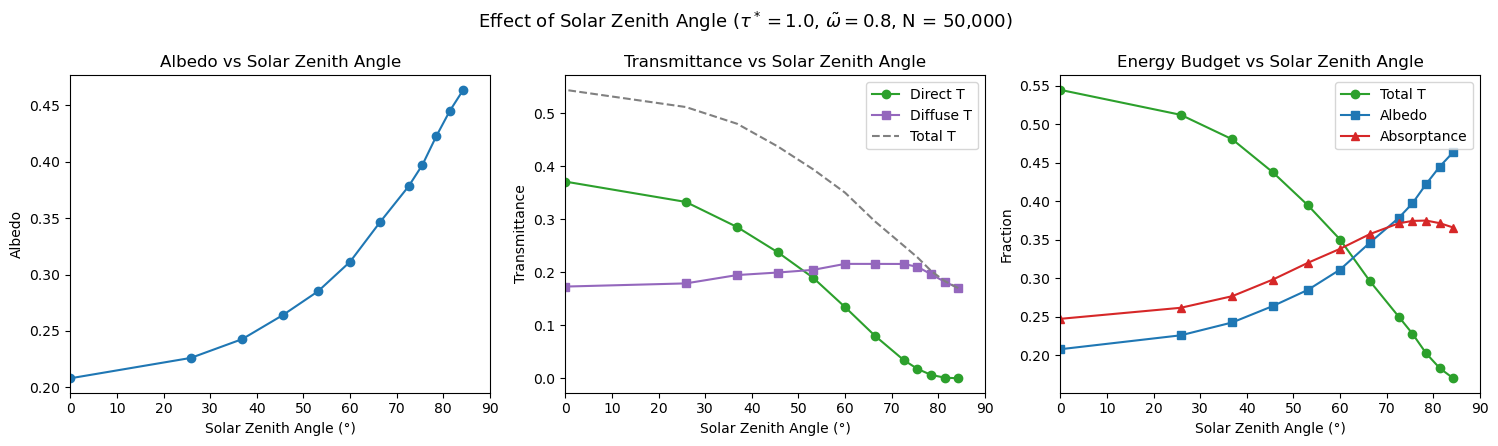

In [27]:
n_photons = 50000
tau_star = 1.0
omega = 0.8

# Vary mu0 from near-grazing to overhead
mu0s = np.array([0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
sza = np.degrees(np.arccos(mu0s))  # solar zenith angle in degrees

results = {'direct_T': [], 'diffuse_T': [], 'total_T': [], 'albedo': [], 'absorptance': []}

for mu in mu0s:
    r = monte_carlo_scattering(n_photons, tau_star, omega=omega, mu0=mu)
    for k in results:
        results[k].append(r[k])

for k in results:
    results[k] = np.array(results[k])

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Albedo vs SZA
axes[0].plot(sza, results['albedo'], 'o-', color='tab:blue')
axes[0].set_xlabel('Solar Zenith Angle (°)')
axes[0].set_ylabel('Albedo')
axes[0].set_title('Albedo vs Solar Zenith Angle')
axes[0].set_xlim(0, 90)

# Panel 2: Direct vs Diffuse T
axes[1].plot(sza, results['direct_T'], 'o-', label='Direct T', color='tab:green')
axes[1].plot(sza, results['diffuse_T'], 's-', label='Diffuse T', color='tab:purple')
axes[1].plot(sza, results['total_T'], '--', label='Total T', color='gray')
axes[1].set_xlabel('Solar Zenith Angle (°)')
axes[1].set_ylabel('Transmittance')
axes[1].set_title('Transmittance vs Solar Zenith Angle')
axes[1].set_xlim(0, 90)
axes[1].legend()

# Panel 3: Full energy budget
axes[2].plot(sza, results['total_T'], 'o-', label='Total T', color='tab:green')
axes[2].plot(sza, results['albedo'], 's-', label='Albedo', color='tab:blue')
axes[2].plot(sza, results['absorptance'], '^-', label='Absorptance', color='tab:red')
axes[2].set_xlabel('Solar Zenith Angle (°)')
axes[2].set_ylabel('Fraction')
axes[2].set_title('Energy Budget vs Solar Zenith Angle')
axes[2].set_xlim(0, 90)
axes[2].legend()

plt.suptitle(rf'Effect of Solar Zenith Angle ($\tau^* = {tau_star}$, $\tilde{{\omega}} = {omega}$, N = {n_photons:,})', fontsize=13)
plt.tight_layout()
plt.savefig('figures/5d.png', dpi=150, bbox_inches='tight')
plt.show()

Albedo increases at higher SZA (lower sun), direct T drops sharply, and absorptance also increases with SZA. A lower sun means a longer path through the atmosphere, giving photons more chances to interact and more interactions means more get scattered back up or absorbed before reaching the surface.

# AI Usage
Tool used: Claude

How it was used: I used Claude to make the functions and the plots.

What I changed: I went over the code, modified the parameters for the plots and interpreted the plots to answer the questions.

How I verified the result: I verifed the results using Beer's law and calculated the total of transmittance, absorptance, and reflectance (=1).